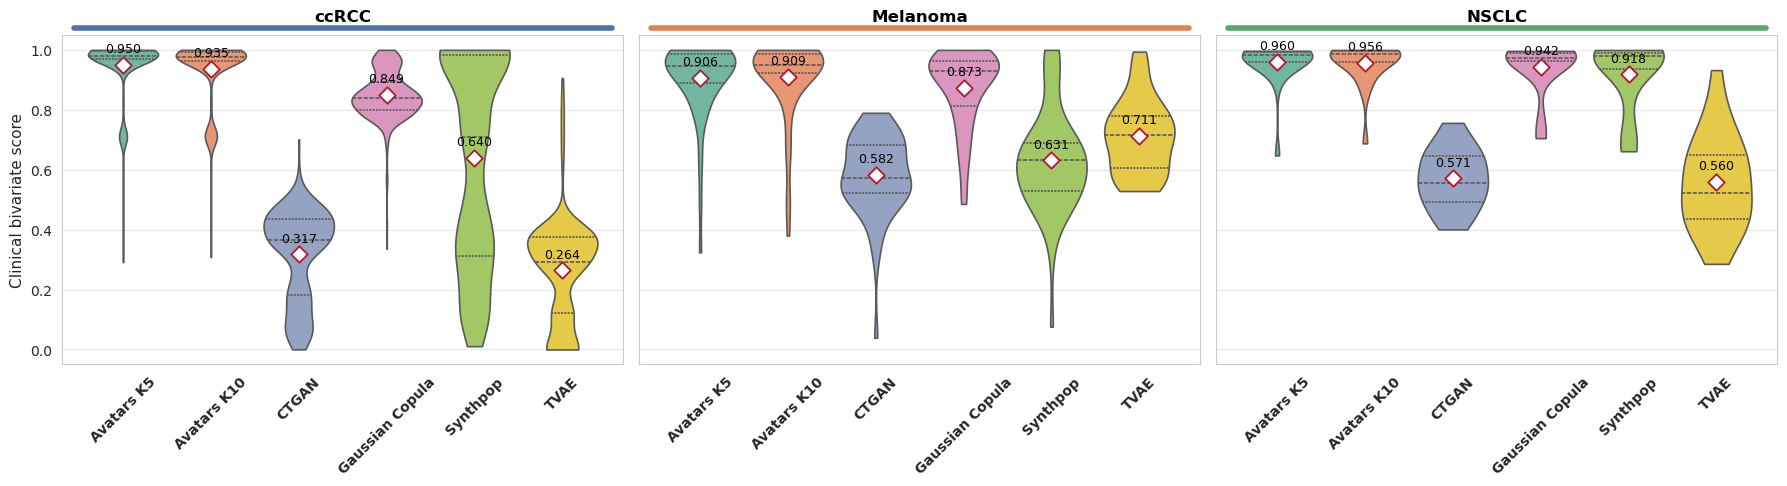

In [ ]:
import pandas as pd
import numpy as np
from SynOmics.metrics.fidelity.visualization import plot_violin_grid_by_cancer
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

DATASET_COLORS = {
    "Avatars K5": "#66c2a5",         # greenish
    "Avatars K10": "#fc8d62",        # orange
    "CTGAN": "#8da0cb",              # blue
    "Gaussian Copula": "#e78ac3",    # pink
    "Synthpop": "#a6d854",           # lime
    "TVAE": "#ffd92f",               # yellow
}

seed = 42
names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
cancers = ['ccRCC', 'Melanoma', 'NSCLC']

datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']

Bivariate_Score_Dict = {}
Bivariate_OmicScore_Dict = {}
Bivariate_CrossScore_Dict = {}
for cancer in cancers:
    score_dict = {}
    score_omic_dict = {}
    cross_score_dict = {}
    for i, dataset in enumerate(datasets):
        
        score = np.load(f'../{cancer}/BroadUtility/PairwiseClinical/PairwiseClinical_{seed}/bivariate_{dataset}_filtered.npy')
        score_omic = np.load(f'../{cancer}/BroadUtility/PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}/{dataset}_filtered.npy')
        crossgroup_df = pd.read_csv(f'../{cancer}/BroadUtility/PairwiseCrossGroup/CrossGroup_{seed}/{dataset}_cross_group_full.csv')
        cross_score = crossgroup_df[crossgroup_df['Original_Correlation']>=0.5]['Score'].values
        
        score_dict[names[i]]=score
        score_omic_dict[names[i]]=score_omic
        cross_score_dict[names[i]]=cross_score
        
    Bivariate_Score_Dict[cancer]=score_dict
    Bivariate_OmicScore_Dict[cancer] = score_omic_dict
    Bivariate_CrossScore_Dict[cancer] = cross_score_dict
    
fig, axes, mean_by_cancer = plot_violin_grid_by_cancer(
    cancer_to_method_scores=Bivariate_Score_Dict,
    value_name="Clinical bivariate score", 
    methods_order=names,
    palette=DATASET_COLORS,  
    figsize=(18, 5),          
    fontsize=11,
    annotate_mean=True,      
    show=True,
)
fig.savefig(f"figure3b_bivariate/clinical_bi_{seed}.pdf", bbox_inches="tight", facecolor="white")


fig_omic, axes, mean_by_cancer = plot_violin_grid_by_cancer(
    cancer_to_method_scores=Bivariate_OmicScore_Dict,
    value_name="Transcriptomic bivariate score", 
    methods_order=names,
    palette=DATASET_COLORS,  
    figsize=(18, 5),          
    fontsize=11,
    annotate_mean=True,      
    show=True,
)
fig_omic.savefig(f"figure3b_bivariate/omic_bi_{seed}.pdf", bbox_inches="tight", facecolor="white")

fig_cross, axes, mean_by_cancer = plot_violin_grid_by_cancer(
    cancer_to_method_scores=Bivariate_CrossScore_Dict,
    value_name="Clinical-Transcriptomic bivariate score", 
    methods_order=names,
    palette=DATASET_COLORS,  
    figsize=(18, 5),          
    fontsize=11,
    annotate_mean=True,      
    show=True,
)
fig_cross.savefig(f"figure3b_bivariate/cross_bi_{seed}.pdf", bbox_inches="tight", facecolor="white")